## Naïve Bayes - Data Preparation


### Step 1: Load and Explore the Data
Before applying the Naïve Bayes classification models, we need to prepare the dataset. The first step is to load the cleaned dataset and examine its structure.

- We use **pandas** to load and inspect the dataset.
- We check for missing values, data types, and categorical columns that might need encoding.

---

In [15]:
import pandas as pd

# Load the cleaned dataset
file_path = "diabetes_cleaned.csv"
df = pd.read_csv(file_path)

# Display the first few rows to understand the dataset
print(df.head())

# Display column data types
print(df.dtypes)


                             Target Genetic Markers Autoantibodies  \
0          Steroid-Induced Diabetes        Positive       Negative   
1  Neonatal Diabetes Mellitus (NDM)        Positive       Negative   
2                       Prediabetic        Positive       Positive   
3                   Type 1 Diabetes        Negative       Positive   
4                  Wolfram Syndrome        Negative       Negative   

  Family History Environmental Factors  Insulin Levels  Age   BMI  \
0             No               Present            40.0   44  38.0   
1             No               Present            13.0   10  17.0   
2            Yes               Present            27.0   36  24.0   
3             No               Present             8.0   10  16.0   
4            Yes               Present            17.0   10  17.0   

  Physical Activity Dietary Habits  ...  Pulmonary Function  \
0              High        Healthy  ...                  76   
1              High        Healthy  ..

## Step 2: Encode Categorical Features
Naïve Bayes models require numerical input features. Any categorical variables must be **converted into numerical representations**.

- We use **Label Encoding** to transform categorical variables into numerical values.
- This step ensures compatibility with the Naïve Bayes classifiers.

---

In [4]:
from sklearn.preprocessing import LabelEncoder

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

# Apply Label Encoding to categorical columns
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Store encoders for inverse transformation if needed

# Display the transformed dataset
print(df.head())
df.to_csv('nb_prepared.csv', index=False)
print("Encoded and saved as 'nb_prepared.csv'")

   Target  Genetic Markers  Autoantibodies  Family History  \
0       7                1               0               0   
1       4                1               0               0   
2       5                1               1               1   
3       8                0               1               0   
4      12                0               0               1   

   Environmental Factors  Insulin Levels  Age   BMI  Physical Activity  \
0                      1            40.0   44  38.0                  0   
1                      1            13.0   10  17.0                  0   
2                      1            27.0   36  24.0                  0   
3                      1             8.0   10  16.0                  1   
4                      1            17.0   10  17.0                  0   

   Dietary Habits  ...  Pulmonary Function  Cystic Fibrosis Diagnosis  \
0               0  ...                  76                          0   
1               0  ...              

### Step 3: Define Features (X) and Target (y)
For classification tasks, we need to separate:
- **X** (independent variables/features)
- **y** (dependent variable/target)

The target variable typically indicates whether a person has diabetes or not.

---

In [16]:
# Assuming the target column is named 'Target' (modify if different)
X = df.drop(columns=['Target'])  # Features
y = df['Target']  # Target variable


### Step 4: Train-Test Split
To evaluate the performance of our Naïve Bayes models, we must **split the dataset** into:
- **Training Set (80%)**: Used to train the model.
- **Testing Set (20%)**: Used to evaluate the model’s accuracy.

This split ensures that the model learns from one set of data and is tested on unseen data.

---

In [10]:
from sklearn.model_selection import train_test_split

# Split the dataset (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Display shapes to confirm correct split
print(f"Training Set: {X_train.shape}, Testing Set: {X_test.shape}")

Training Set: (56000, 33), Testing Set: (14000, 33)


In [13]:
# Combine feature and target columns for training and testing data
nb_train_preview = X_train.copy()
nb_train_preview["Target"] = y_train

nb_test_preview = X_test.copy()
nb_test_preview["Target"] = y_test

# Display top 5 rows from each
print("Training Data Sample:")
display(nb_train_preview.head(100))

print("Testing Data Sample:")
display(nb_test_preview.head(100))

# Optional: Save to CSV for screenshots or linking
nb_train_preview.head(100).to_csv("naivebayes_train_sample.csv", index=False)
nb_test_preview.head(100).to_csv("naivebayes_test_sample.csv", index=False)


Training Data Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,Target
47339,0,1,0,0,12.0,52,31.0,1,0,126,...,1,0,1,2,0,43,1,2765,1,2
67456,0,1,1,1,48.0,68,34.0,2,1,149,...,1,0,1,2,0,43,2,2901,1,6
12308,1,0,1,1,37.0,51,34.0,2,1,108,...,0,0,1,1,1,51,1,3825,1,2
32557,1,0,1,0,27.0,19,22.0,2,0,107,...,1,0,0,1,0,52,2,2707,1,3
664,0,1,0,0,18.0,23,18.0,0,1,119,...,0,1,0,2,0,67,0,3220,1,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22814,1,1,0,0,47.0,68,27.0,0,0,136,...,0,0,1,3,0,69,3,2841,1,9
15742,0,0,0,0,20.0,63,38.0,2,0,134,...,1,0,1,3,0,46,1,3292,1,7
14104,1,1,1,1,20.0,17,26.0,1,1,105,...,1,1,0,1,1,46,3,2854,0,0
41655,1,1,1,0,48.0,53,28.0,1,0,115,...,0,1,0,2,1,62,0,4297,1,7


Testing Data Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms,Target
46730,0,1,0,1,34.0,54,32.0,2,1,119,...,0,0,0,2,0,63,1,2533,0,6
48393,1,1,0,0,43.0,74,32.0,1,0,123,...,1,1,0,2,0,57,2,2634,1,9
41416,0,1,0,1,20.0,57,27.0,1,1,116,...,0,0,1,3,0,42,1,3947,1,7
34506,0,1,1,0,17.0,30,39.0,0,1,122,...,0,1,1,3,1,91,3,3237,1,9
43725,1,1,0,0,15.0,28,21.0,0,0,103,...,1,0,0,1,0,55,0,2634,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20958,0,1,1,1,17.0,12,24.0,1,0,105,...,0,0,1,2,0,16,0,2692,1,11
57200,0,0,1,1,22.0,33,23.0,2,0,105,...,1,1,0,1,1,42,3,3632,1,2
46957,0,0,0,1,19.0,17,16.0,0,0,87,...,1,0,1,2,1,11,0,1815,1,12
58163,1,1,0,1,34.0,57,28.0,1,1,111,...,1,0,1,2,0,68,0,3548,1,2


## Step 5: Convert Data for Different NB Models
Naïve Bayes has different variants, and each requires data in a specific format:

- **Gaussian Naïve Bayes** → Works with **continuous** numerical features.
- **Multinomial Naïve Bayes** → Works with **integer-based** count features.
- **Bernoulli Naïve Bayes** → Works with **binary features (0s and 1s only).**

To handle this:
- We **normalize continuous data** for GaussianNB.
- We **convert features to integer values** for MultinomialNB.
- We **binarize data (convert to 0s and 1s)** for BernoulliNB.

After completing these transformations, the dataset is **ready for Naïve Bayes modeling**.

---

In [17]:
from sklearn.preprocessing import MinMaxScaler, Binarizer

# Convert for GaussianNB (continuous remains the same)
X_train_gaussian, X_test_gaussian = X_train.copy(), X_test.copy()

# Convert for MultinomialNB (integer values)
X_train_multinomial, X_test_multinomial = X_train.copy(), X_test.copy()
X_train_multinomial = X_train_multinomial.astype(int)
X_test_multinomial = X_test_multinomial.astype(int)

# Convert for BernoulliNB (binary features)
binarizer = Binarizer(threshold=0.5)
X_train_bernoulli = binarizer.fit_transform(X_train)
X_test_bernoulli = binarizer.transform(X_test)

print("Data prepared for Naïve Bayes Models")
# Display the first few rows of each dataset
print("GaussianNB Training Data Sample:")
display(X_train_gaussian.head(10))
print("GaussianNB Testing Data Sample:")
display(X_test_gaussian.head(10))

Data prepared for Naïve Bayes Models
GaussianNB Training Data Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
47339,0,1,0,0,12.0,52,31.0,1,0,126,...,77,1,0,1,2,0,43,1,2765,1
67456,0,1,1,1,48.0,68,34.0,2,1,149,...,60,1,0,1,2,0,43,2,2901,1
12308,1,0,1,1,37.0,51,34.0,2,1,108,...,88,0,0,1,1,1,51,1,3825,1
32557,1,0,1,0,27.0,19,22.0,2,0,107,...,73,1,0,0,1,0,52,2,2707,1
664,0,1,0,0,18.0,23,18.0,0,1,119,...,77,0,1,0,2,0,67,0,3220,1
21003,1,0,0,1,40.0,76,32.0,0,1,132,...,63,0,0,1,2,0,48,1,3138,0
29637,0,1,0,0,12.0,10,12.0,1,1,72,...,60,0,0,0,2,1,26,0,1937,1
57937,1,0,1,1,6.0,27,23.0,2,1,114,...,76,0,1,1,1,0,47,1,2763,1
23680,0,0,0,0,33.0,43,27.0,2,0,119,...,81,1,1,0,1,0,65,1,2628,0
26306,0,1,1,0,17.0,16,24.0,1,1,101,...,45,0,1,0,1,0,17,1,1984,1


GaussianNB Testing Data Sample:


,Genetic Markers,Autoantibodies,Family History,Environmental Factors,Insulin Levels,Age,BMI,Physical Activity,Dietary Habits,Blood Pressure,...,Pulmonary Function,Cystic Fibrosis Diagnosis,Steroid Use History,Genetic Testing,Neurological Assessments,Liver Function Tests,Digestive Enzyme Levels,Urine Test,Birth Weight,Early Onset Symptoms
46730,0,1,0,1,34.0,54,32.0,2,1,119,...,67,0,0,0,2,0,63,1,2533,0
48393,1,1,0,0,43.0,74,32.0,1,0,123,...,70,1,1,0,2,0,57,2,2634,1
41416,0,1,0,1,20.0,57,27.0,1,1,116,...,65,0,0,1,3,0,42,1,3947,1
34506,0,1,1,0,17.0,30,39.0,0,1,122,...,61,0,1,1,3,1,91,3,3237,1
43725,1,1,0,0,15.0,28,21.0,0,0,103,...,88,1,0,0,1,0,55,0,2634,0
11615,0,0,0,0,29.0,52,22.0,2,1,146,...,74,1,0,1,2,1,69,2,3975,1
24656,1,1,0,1,25.0,28,28.0,0,0,110,...,85,0,1,0,2,1,64,2,3301,1
22411,0,0,0,1,27.0,61,37.0,0,0,116,...,61,0,1,1,2,1,54,2,2755,0
936,0,0,0,1,13.0,34,27.0,2,0,112,...,77,0,0,1,1,1,77,2,2929,1
56364,1,1,1,0,36.0,42,31.0,1,1,127,...,83,0,0,1,2,1,33,0,2785,0


Accuracy of GaussianNB: 0.8193

Classification Report for GaussianNB:

              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1070
           1       0.79      0.83      0.81      1072
           2       0.89      0.89      0.89      1072
           3       0.82      0.81      0.81      1194
           4       0.96      1.00      0.98      1018
           5       0.92      0.92      0.92      1089
           6       0.69      0.63      0.66      1053
           7       0.70      0.68      0.69      1048
           8       0.82      0.89      0.85      1123
           9       0.74      0.75      0.74      1083
          10       0.71      0.76      0.73      1064
          11       0.83      0.86      0.85      1063
          12       0.89      0.82      0.85      1051

    accuracy                           0.82     14000
   macro avg       0.82      0.82      0.82     14000
weighted avg       0.82      0.82      0.82     14000



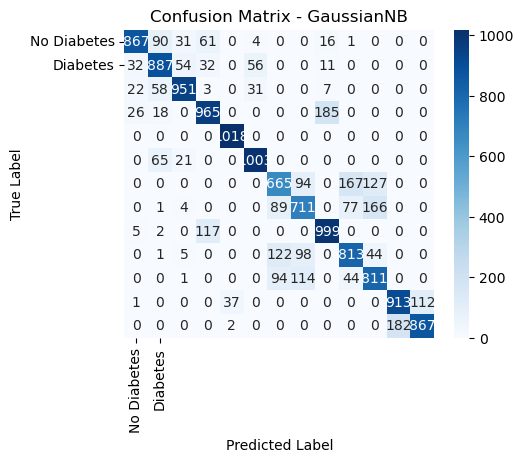

Accuracy of MultinomialNB: 0.5474

Classification Report for MultinomialNB:

              precision    recall  f1-score   support

           0       0.45      0.47      0.46      1070
           1       0.37      0.44      0.40      1072
           2       0.59      0.58      0.58      1072
           3       0.57      0.55      0.56      1194
           4       0.85      0.80      0.82      1018
           5       0.52      0.54      0.53      1089
           6       0.41      0.47      0.43      1053
           7       0.44      0.33      0.38      1048
           8       0.74      0.69      0.71      1123
           9       0.44      0.49      0.47      1083
          10       0.50      0.43      0.46      1064
          11       0.65      0.55      0.60      1063
          12       0.65      0.78      0.71      1051

    accuracy                           0.55     14000
   macro avg       0.55      0.55      0.55     14000
weighted avg       0.55      0.55      0.55     14000



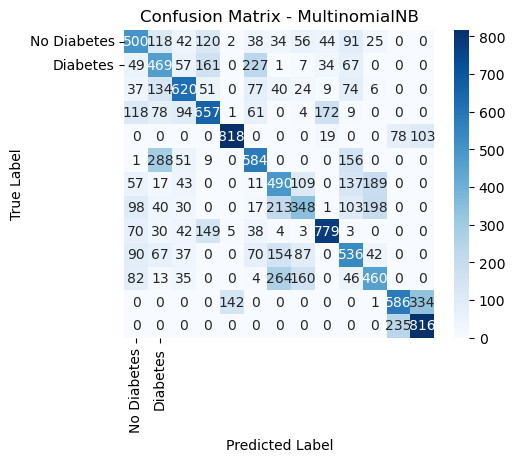

Accuracy of BernoulliNB: 0.0942

Classification Report for BernoulliNB:

              precision    recall  f1-score   support

           0       0.08      0.11      0.09      1070
           1       0.07      0.04      0.05      1072
           2       0.06      0.04      0.05      1072
           3       0.09      0.15      0.11      1194
           4       0.05      0.00      0.00      1018
           5       0.07      0.11      0.09      1089
           6       0.08      0.17      0.11      1053
           7       0.07      0.02      0.03      1048
           8       0.10      0.07      0.08      1123
           9       0.09      0.14      0.11      1083
          10       0.09      0.14      0.11      1064
          11       0.44      0.12      0.19      1063
          12       0.43      0.09      0.15      1051

    accuracy                           0.09     14000
   macro avg       0.13      0.09      0.09     14000
weighted avg       0.13      0.09      0.09     14000



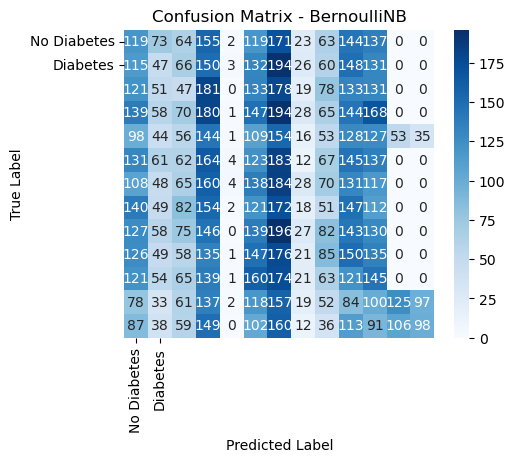

In [6]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Function to train and evaluate models
def evaluate_nb_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy of {model_name}: {accuracy:.4f}")
    
    # Classification Report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Gaussian Naïve Bayes (For continuous data)
gnb = GaussianNB()
evaluate_nb_model(gnb, X_train_gaussian, X_test_gaussian, y_train, y_test, "GaussianNB")

# Multinomial Naïve Bayes (For categorical data)
mnb = MultinomialNB()
evaluate_nb_model(mnb, X_train_multinomial, X_test_multinomial, y_train, y_test, "MultinomialNB")

# Bernoulli Naïve Bayes (For binary data)
bnb = BernoulliNB()
evaluate_nb_model(bnb, X_train_bernoulli, X_test_bernoulli, y_train, y_test, "BernoulliNB")

Accuracy of GaussianNB: 0.8193

Classification Report for GaussianNB:

              precision    recall  f1-score   support

           0       0.91      0.81      0.86      1070
           1       0.79      0.83      0.81      1072
           2       0.89      0.89      0.89      1072
           3       0.82      0.81      0.81      1194
           4       0.96      1.00      0.98      1018
           5       0.92      0.92      0.92      1089
           6       0.69      0.63      0.66      1053
           7       0.70      0.68      0.69      1048
           8       0.82      0.89      0.85      1123
           9       0.74      0.75      0.74      1083
          10       0.71      0.76      0.73      1064
          11       0.83      0.86      0.85      1063
          12       0.89      0.82      0.85      1051

    accuracy                           0.82     14000
   macro avg       0.82      0.82      0.82     14000
weighted avg       0.82      0.82      0.82     14000



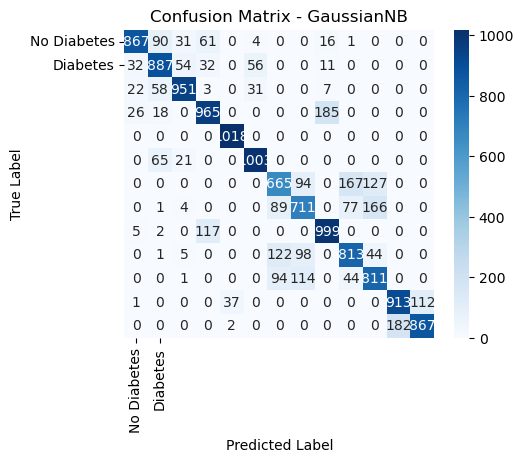

Accuracy of MultinomialNB: 0.5474

Classification Report for MultinomialNB:

              precision    recall  f1-score   support

           0       0.45      0.47      0.46      1070
           1       0.37      0.44      0.40      1072
           2       0.59      0.58      0.58      1072
           3       0.57      0.55      0.56      1194
           4       0.85      0.80      0.82      1018
           5       0.52      0.54      0.53      1089
           6       0.41      0.47      0.43      1053
           7       0.44      0.33      0.38      1048
           8       0.74      0.69      0.71      1123
           9       0.44      0.49      0.47      1083
          10       0.50      0.43      0.46      1064
          11       0.65      0.55      0.60      1063
          12       0.65      0.78      0.71      1051

    accuracy                           0.55     14000
   macro avg       0.55      0.55      0.55     14000
weighted avg       0.55      0.55      0.55     14000



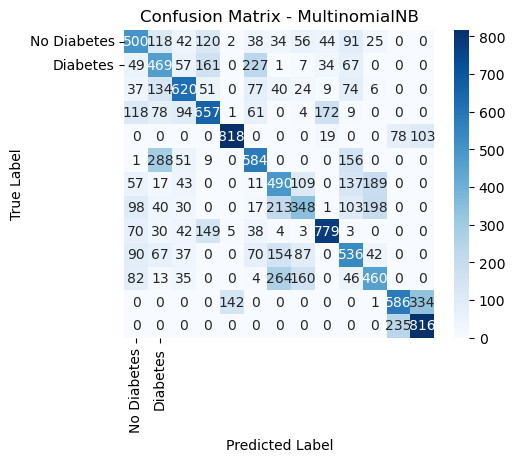

Accuracy of BernoulliNB: 0.0942

Classification Report for BernoulliNB:

              precision    recall  f1-score   support

           0       0.08      0.11      0.09      1070
           1       0.07      0.04      0.05      1072
           2       0.06      0.04      0.05      1072
           3       0.09      0.15      0.11      1194
           4       0.05      0.00      0.00      1018
           5       0.07      0.11      0.09      1089
           6       0.08      0.17      0.11      1053
           7       0.07      0.02      0.03      1048
           8       0.10      0.07      0.08      1123
           9       0.09      0.14      0.11      1083
          10       0.09      0.14      0.11      1064
          11       0.44      0.12      0.19      1063
          12       0.43      0.09      0.15      1051

    accuracy                           0.09     14000
   macro avg       0.13      0.09      0.09     14000
weighted avg       0.13      0.09      0.09     14000



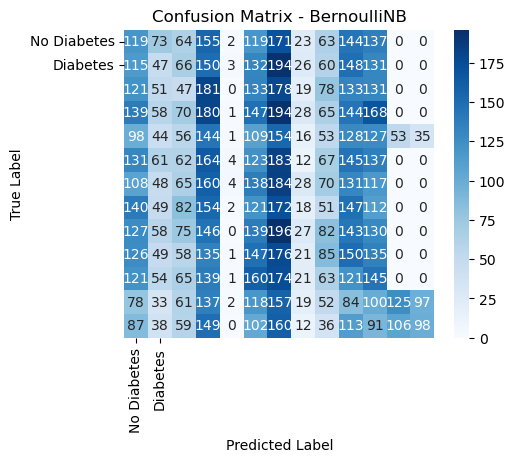


Stored Accuracy Scores: {'GaussianNB': 0.8192857142857143, 'MultinomialNB': 0.5473571428571429, 'BernoulliNB': 0.09421428571428571}


In [7]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionary to store results
nb_results = {
    "accuracy": {},
    "classification_reports": {},
    "confusion_matrices": {}
}

# Function to train and evaluate models and store results
def evaluate_nb_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Store Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    nb_results["accuracy"][model_name] = accuracy
    
    # Store Classification Report
    nb_results["classification_reports"][model_name] = classification_report(y_test, y_pred, output_dict=True)
    
    # Store Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    nb_results["confusion_matrices"][model_name] = cm

    # Print Accuracy
    print(f"Accuracy of {model_name}: {accuracy:.4f}")

    # Print Classification Report
    print(f"\nClassification Report for {model_name}:\n")
    print(classification_report(y_test, y_pred))

    # Plot Confusion Matrix
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Diabetes', 'Diabetes'], yticklabels=['No Diabetes', 'Diabetes'])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

# Gaussian Naïve Bayes
gnb = GaussianNB()
evaluate_nb_model(gnb, X_train_gaussian, X_test_gaussian, y_train, y_test, "GaussianNB")

# Multinomial Naïve Bayes
mnb = MultinomialNB()
evaluate_nb_model(mnb, X_train_multinomial, X_test_multinomial, y_train, y_test, "MultinomialNB")

# Bernoulli Naïve Bayes
bnb = BernoulliNB()
evaluate_nb_model(bnb, X_train_bernoulli, X_test_bernoulli, y_train, y_test, "BernoulliNB")

# Display stored results
print("\nStored Accuracy Scores:", nb_results["accuracy"])


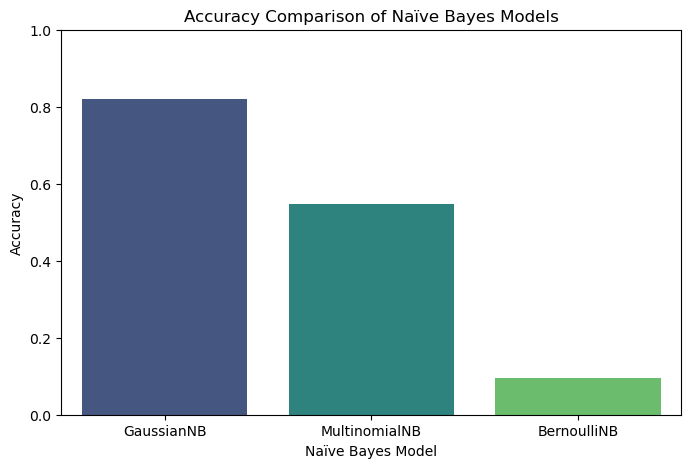

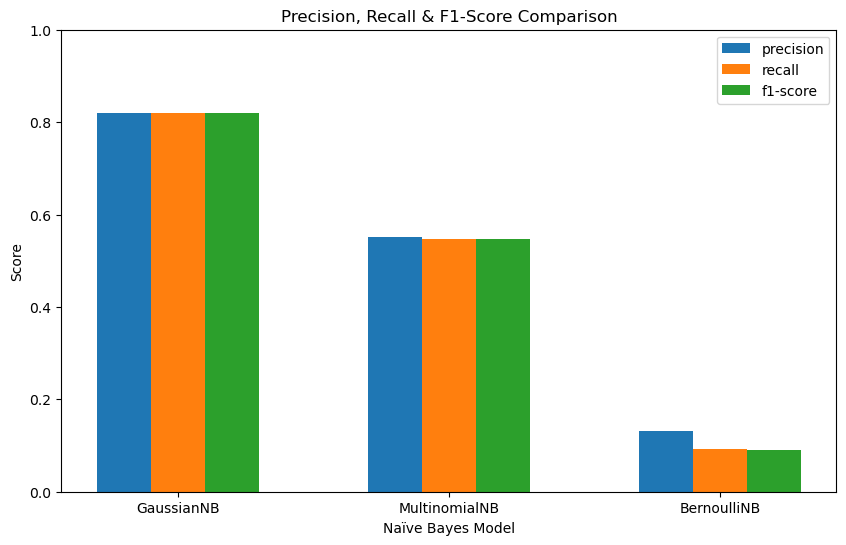

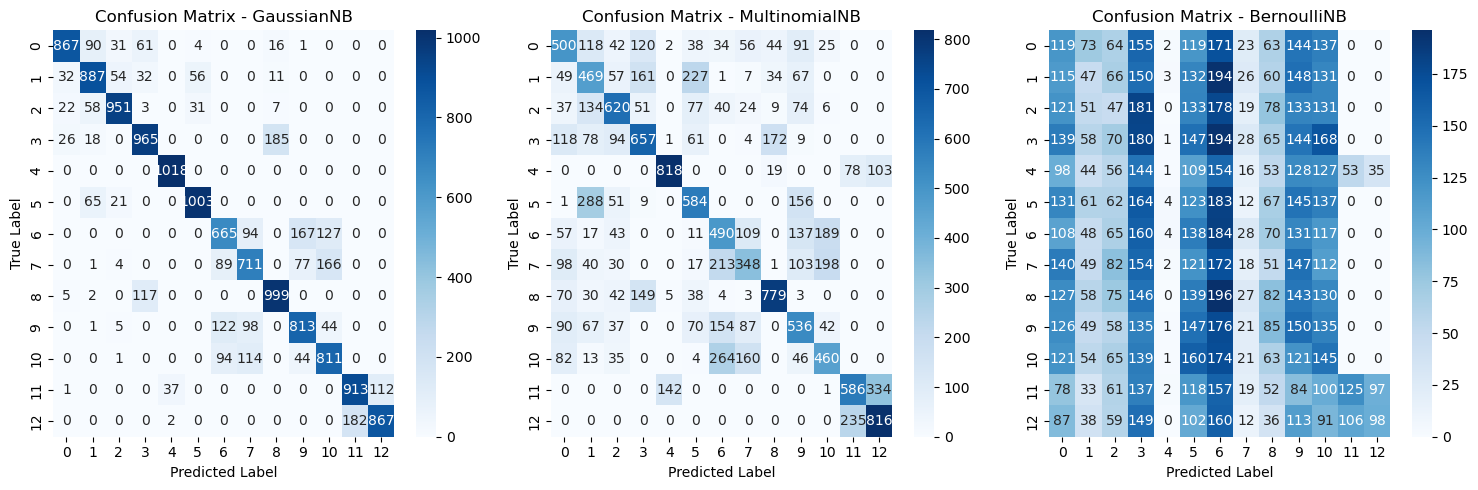

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to plot accuracy comparison
def plot_accuracy(nb_results):
    plt.figure(figsize=(8, 5))
    models = list(nb_results["accuracy"].keys())
    accuracies = list(nb_results["accuracy"].values())

    sns.barplot(x=models, y=accuracies, palette="viridis")
    plt.ylim(0, 1)  # Accuracy is between 0 and 1
    plt.ylabel("Accuracy")
    plt.xlabel("Naïve Bayes Model")
    plt.title("Accuracy Comparison of Naïve Bayes Models")
    plt.show()

# Function to plot precision, recall, and F1-score comparison
def plot_classification_metrics(nb_results):
    metrics = ["precision", "recall", "f1-score"]
    models = list(nb_results["classification_reports"].keys())

    scores = {metric: [] for metric in metrics}

    # Extract macro avg scores for precision, recall, and f1-score
    for model in models:
        for metric in metrics:
            scores[metric].append(nb_results["classification_reports"][model]["macro avg"][metric])

    x = np.arange(len(models))  # Label locations
    width = 0.2  # Width of the bars

    fig, ax = plt.subplots(figsize=(10, 6))
    
    for i, metric in enumerate(metrics):
        ax.bar(x + i * width, scores[metric], width, label=metric)

    ax.set_xticks(x + width)
    ax.set_xticklabels(models)
    ax.set_ylim(0, 1)
    ax.set_xlabel("Naïve Bayes Model")
    ax.set_ylabel("Score")
    ax.set_title("Precision, Recall & F1-Score Comparison")
    ax.legend()

    plt.show()

# Function to plot confusion matrices side by side
def plot_confusion_matrices(nb_results):
    models = list(nb_results["confusion_matrices"].keys())

    fig, axes = plt.subplots(1, len(models), figsize=(15, 5))
    
    for i, model in enumerate(models):
        sns.heatmap(nb_results["confusion_matrices"][model], annot=True, fmt="d", cmap="Blues", ax=axes[i])
        axes[i].set_title(f"Confusion Matrix - {model}")
        axes[i].set_xlabel("Predicted Label")
        axes[i].set_ylabel("True Label")

    plt.tight_layout()
    plt.show()

# Call functions to generate visual comparisons
plot_accuracy(nb_results)
plot_classification_metrics(nb_results)
plot_confusion_matrices(nb_results)


## Naïve Bayes Model: Final Discussion and Conclusion

In this section, we evaluated and compared the performance of three Naïve Bayes classifiers on a multi-class diabetes dataset:

- **Gaussian Naïve Bayes**
- **Multinomial Naïve Bayes**
- **Bernoulli Naïve Bayes**

---

### Overall Performance Summary

| Model               | Accuracy | Macro Avg F1-Score | Weighted Avg F1-Score |
|--------------------|----------|--------------------|------------------------|
| GaussianNB         | 82%      | 0.82               | 0.82                   |
| MultinomialNB      | 55%      | 0.55               | 0.55                   |
| BernoulliNB        | 9%       | 0.09               | 0.09                   |

---

### **Gaussian Naïve Bayes (Best Performer)**

- Achieved the **highest accuracy** at **82%**.
- Strong precision, recall, and F1-scores across nearly all classes.
- This algorithm works well because it assumes feature distributions follow a Gaussian (normal) distribution, which aligns well with the **continuous nature of the dataset** after normalization.
- Confusion matrix shows **clear diagonal dominance**, indicating excellent class separation.

---

### **Multinomial Naïve Bayes**

- Performed **moderately well** with **55% accuracy**.
- Works best with **discrete count-based data**, such as word frequencies in text classification.
- The dataset, even though encoded, doesn’t represent counts; hence, **limited compatibility**.
- Confusion matrix indicates several misclassifications and **class overlaps**, particularly in the middle classes.

---

### **Bernoulli Naïve Bayes (Poor Performer)**

- Extremely poor accuracy at only **9%**.
- Designed for **binary features**, where inputs are either 0 or 1.
- The dataset's features were not naturally binary, so binarization led to a significant **loss of information**.
- Confusion matrix displays **very weak prediction capability**, with heavy misclassification across all classes.

---

### Visual Insight

- **Bar plots** of accuracy and F1-scores visually highlight the **dominance of GaussianNB** over the other two models.
- Comparative confusion matrices reaffirm the **GaussianNB model’s robustness** and justify its suitability for this dataset.

---

### Final Takeaways

- **GaussianNB is highly effective** for datasets with continuous numerical features that follow a bell-curve distribution.
- **MultinomialNB** can be a fallback but only if features represent **count data**.
- **BernoulliNB** should be avoided for this problem unless the dataset is naturally **binary**.

> ✨ Based on this analysis, **Gaussian Naïve Bayes** is the **most suitable choice** for the diabetes prediction problem in this project.
